In [2]:
import zipfile
import os

zip_path = "/content/checkpoint-2260_classification.zip"
extract_path = "/content/checkpoint-2260_classification"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [1]:
import os
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
model_name = 'unsloth/Llama-3.2-3B-Instruct'
num_classes = 3
max_seq_length = 512

In [4]:
train_path = "/content/twitter_training_3class.csv"
valid_path = "/content/twitter_valid_3class.csv"
test_path = "/content/twitter_testing_3class.csv"

In [5]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "right"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [6]:
system_prompt = """Classify sentiment towards the 'Target Entity' as [Others, Negative, Positive].

Focus exclusively on emotion directed AT the Target Entity:
- Positive: The text expresses explicit praise, enjoyment, or uses positive gaming slang ("killed it") directed specifically at the Target Entity.
- Negative: The text expresses direct complaints, deep frustration, or insults directed specifically at the Target Entity.

If it is not clearly Positive or Negative toward the Target Entity, classify it as:
- Others: The catch-all category. Use this if the text is objective/neutral, if the Target Entity is missing entirely, OR if the text contains strong emotions (like "love", "hate", or "thank you") that are directed at someone or something else."""

In [7]:
def format_with_system_prompt(row):
    user_text = row['tweet']

    # Extract the entity from your dataset
    # (Make sure 'entity' matches the exact column name in your CSV)
    target_entity = row['entity']

    # Prepend the system prompt, the specific entity, and the text
    full_text = f"{system_prompt}\n\nTarget Entity: {target_entity}\nText: {user_text}"

    return {"formatted_text": full_text}

In [8]:
from datasets import load_dataset

raw_datasets = load_dataset(
    "csv",
    data_files={
        "train": train_path,
        "validation": valid_path,
        "test": test_path
    }
)

print(raw_datasets)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet_id', 'entity', 'sentiment', 'tweet'],
        num_rows: 9032
    })
    validation: Dataset({
        features: ['tweet_id', 'entity', 'sentiment', 'tweet'],
        num_rows: 1129
    })
    test: Dataset({
        features: ['tweet_id', 'entity', 'sentiment', 'tweet'],
        num_rows: 1130
    })
})


In [9]:
formatted_datasets = raw_datasets.map(format_with_system_prompt)

Map:   0%|          | 0/9032 [00:00<?, ? examples/s]

Map:   0%|          | 0/1129 [00:00<?, ? examples/s]

Map:   0%|          | 0/1130 [00:00<?, ? examples/s]

In [10]:
def tokenize_function(examples):

    tokenized_inputs = tokenizer(
        examples["formatted_text"],
        truncation=True,
        max_length=308
    )

    tokenized_inputs["labels"] = examples["sentiment"]

    return tokenized_inputs

In [11]:
tokenized_datasets = formatted_datasets.map(tokenize_function, batched=True)

cols_to_remove = formatted_datasets["train"].column_names
tokenized_datasets = tokenized_datasets.remove_columns(cols_to_remove)

# Optional: Print the remaining columns just to verify!
print(tokenized_datasets["train"].column_names)

Map:   0%|          | 0/9032 [00:00<?, ? examples/s]

Map:   0%|          | 0/1129 [00:00<?, ? examples/s]

Map:   0%|          | 0/1130 [00:00<?, ? examples/s]

['input_ids', 'attention_mask', 'labels']


In [12]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

In [13]:
!pip install -U bitsandbytes>=0.46.1

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    quantization_config=bnb_config,
    device_map={"": 0}
)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: unsloth/Llama-3.2-3B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
model.config.pad_token_id = tokenizer.pad_token_id
model = prepare_model_for_kbit_training(model)

In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.2,
    bias="none",
    task_type="SEQ_CLS"
)

In [ ]:
model = get_peft_model(model, lora_config)
model.config.use_cache = False

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [17]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
training_args = TrainingArguments(
    output_dir="./llama_sentiment_model",

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-4,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio = 0.1,

    num_train_epochs=6,
    weight_decay=0.01,
    max_grad_norm=0.3,

    # Evaluation and Checkpointing
    logging_strategy="steps",
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    report_to="none"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
trainer.train(resume_from_checkpoint="/kaggle/input/datasets/aryan7004/checkpoint")

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy
3,0.836671,0.711662,0.735281
4,0.631864,0.866997,0.737937


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
Could not locate the best model at ./llama_sentiment_model/checkpoint-1130/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


TrainOutput(global_step=2260, training_loss=0.3548492762894757, metrics={'train_runtime': 7259.2818, 'train_samples_per_second': 7.465, 'train_steps_per_second': 0.467, 'total_flos': 1.278392259072983e+17, 'train_loss': 0.3548492762894757, 'epoch': 4.0})

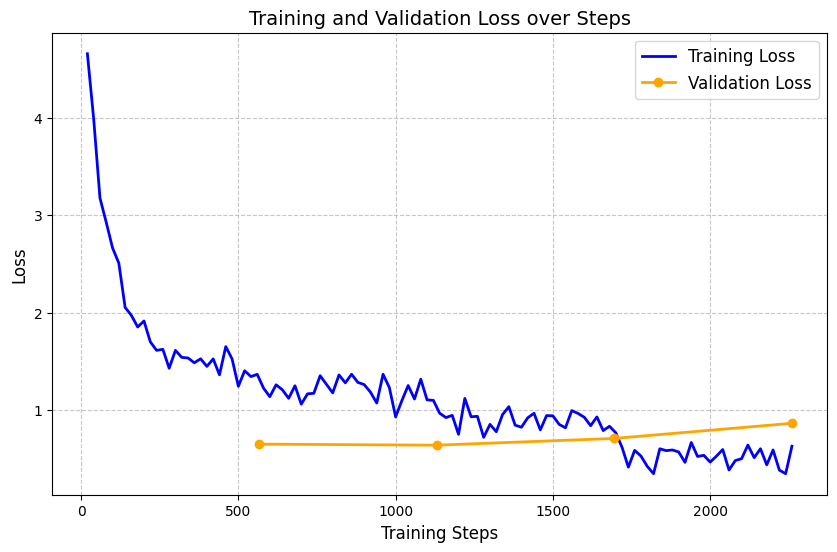

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = []
train_losses = []
eval_steps = []
eval_losses = []

for entry in log_history:
    if 'loss' in entry:
        train_steps.append(entry['step'])
        train_losses.append(entry['loss'])
    elif 'eval_loss' in entry:
        eval_steps.append(entry['step'])
        eval_losses.append(entry['eval_loss'])

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, label='Training Loss', color='blue', linewidth=2)

if eval_steps:
    plt.plot(eval_steps, eval_losses, label='Validation Loss', color='orange', marker='o', linewidth=2)

plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss over Steps', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

In [18]:
from peft import PeftModel

model = PeftModel.from_pretrained(
    model,
    "/content/checkpoint-2260_classification"
)

In [21]:
eval_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=8,
    collate_fn=data_collator
)

In [22]:
all_predictions = []
all_true_labels = []
all_probs = []

model.eval()

with torch.no_grad():
    for batch in tqdm(eval_dataloader, desc="Evaluating"):

        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['labels'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(logits, dim=-1)

        all_predictions.extend(preds.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

Evaluating:   0%|          | 0/142 [00:00<?, ?it/s]

In [23]:
print("Predictions:", len(all_predictions))
print("True labels:", len(all_true_labels))
print("Probabilities:", len(all_probs))

Predictions: 1130
True labels: 1130
Probabilities: 1130


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import numpy as np

y_true = np.array(all_true_labels)
y_pred = np.array(all_predictions)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
roc_auc = roc_auc_score(y_true, np.array(all_probs), multi_class='ovr', average='weighted')


print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.7416
Precision : 0.7414
Recall    : 0.7416
F1 Score  : 0.7407
ROC-AUC   : 0.8785


In [28]:
eval_df = pd.read_csv('/content/twitter_testing_3class.csv')

In [26]:
label_map = {0: "Other", 1: "Negative", 2: "Positive"}

results_df = pd.DataFrame({
    'tweet_text': eval_df['tweet'].tolist(),
    'true_label_num': all_true_labels,
    'predicted_label_num': all_predictions
})

errors_df = results_df[results_df['true_label_num'] != results_df['predicted_label_num']]

print(f"Total Evaluation Size: {len(results_df)}")
print(f"Total Errors Made: {len(errors_df)}")
print(f"Accuracy: {((len(results_df) - len(errors_df)) / len(results_df)) * 100:.2f}%\n")
print("="*50)
print("EXAMPLES OF INCORRECT PREDICTIONS ")
print("="*50)

for index, row in errors_df.head(20).iterrows():
    actual_str = label_map.get(row['true_label_num'], "Unknown")
    pred_str = label_map.get(row['predicted_label_num'], "Unknown")

    print(f"TEXT:     {row['tweet_text']}")
    print(f"ACTUAL:   {actual_str}")
    print(f"PREDICTED: {pred_str}")
    print("-" * 50)

Total Evaluation Size: 1130
Total Errors Made: 292
Accuracy: 74.16%

EXAMPLES OF INCORRECT PREDICTIONS 
TEXT:     just hanging out and playing hearthstone badly .
ACTUAL:   Positive
PREDICTED: Negative
--------------------------------------------------
TEXT:     in activision blizzards latest deal with google overwatch call of duty and hearthstone bring esports exclusively to youtube but the way it all went down could do some real damage.
ACTUAL:   Other
PREDICTED: Negative
--------------------------------------------------
TEXT:     i will believe it when i see it but every way i am excited
ACTUAL:   Other
PREDICTED: Positive
--------------------------------------------------
TEXT:     the greatest shatter in overwatch pic.
ACTUAL:   Negative
PREDICTED: Positive
--------------------------------------------------
TEXT:     fall guys servers are on fire again let us switch to
ACTUAL:   Positive
PREDICTED: Other
--------------------------------------------------
TEXT:     and the reason 

In [29]:
import torch.nn.functional as F

print("Running evaluation to capture all probabilities...")
model.eval()

all_predictions = []
all_true_labels = []
all_probabilities = []

with torch.no_grad():
    for batch in tqdm(eval_dataloader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['labels'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        probs = F.softmax(logits, dim=-1)

        predictions = torch.argmax(probs, dim=-1)

        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probs.cpu().numpy())

label_map = {0: "Other", 1: "Negative", 2: "Positive"}



results_df = pd.DataFrame({
    'tweet_text': eval_df['tweet'].tolist(),
    'actual': [label_map.get(label, "Unknown") for label in all_true_labels],
    'predicted': [label_map.get(pred, "Unknown") for pred in all_predictions],
    'probs': all_probabilities # This holds [score_0, score_1, score_2, score_3]
})

errors_df = results_df[results_df['actual'] != results_df['predicted']]

print("\n" + "="*80)
print(" MISCLASSIFIED EXAMPLES WITH FULL CONFIDENCE SPREAD ")
print("="*80)

for index, row in errors_df.head(20).iterrows():
    p = row['probs']

    print(f"TEXT:       {row['tweet_text']}")
    print(f"ACTUAL:     {row['actual']}")
    print(f"PREDICTED:  {row['predicted']}")

    print("SCORES:     "
          f"Other: {p[0]:>6.2%} | "
          f"Negative: {p[1]:>6.2%} | "
          f"Positive: {p[2]:>6.2%} | ")
    print("-" * 80)

Running evaluation to capture all probabilities...


Evaluating:   0%|          | 0/142 [00:00<?, ?it/s]


 MISCLASSIFIED EXAMPLES WITH FULL CONFIDENCE SPREAD 
TEXT:       just hanging out and playing hearthstone badly .
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other:  8.19% | Negative: 74.84% | Positive: 16.97% | 
--------------------------------------------------------------------------------
TEXT:       in activision blizzards latest deal with google overwatch call of duty and hearthstone bring esports exclusively to youtube but the way it all went down could do some real damage.
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other: 45.29% | Negative: 53.49% | Positive:  1.21% | 
--------------------------------------------------------------------------------
TEXT:       i will believe it when i see it but every way i am excited
ACTUAL:     Other
PREDICTED:  Positive
SCORES:     Other: 12.70% | Negative:  7.64% | Positive: 79.66% | 
--------------------------------------------------------------------------------
TEXT:       the greatest shatter in overwatch pic.
ACTUAL:

In [30]:
pos_to_neg_errors = results_df[(results_df['actual'] == 'Positive') & (results_df['predicted'] == 'Negative')]

neg_to_pos_errors = results_df[(results_df['actual'] == 'Negative') & (results_df['predicted'] == 'Positive')]


def print_error_examples(df, title, num_examples=20):
    print("\n" + "="*80)
    print(f" {title} (Total found: {len(df)})")
    print("="*80)

    for index, row in df.head(num_examples).iterrows():
        p = row['probs']

        print(f"TEXT:       {row['tweet_text']}")
        print(f"ACTUAL:     {row['actual']}")
        print(f"PREDICTED:  {row['predicted']}")
        print("SCORES:     "
              f"Other: {p[0]:>6.2%} | "
              f"Negative: {p[1]:>6.2%} | "
              f"Positive: {p[2]:>6.2%} | ")
        print("-" * 80)

print_error_examples(pos_to_neg_errors, "ACTUAL: POSITIVE -> PREDICTED: NEGATIVE", 20)

print_error_examples(neg_to_pos_errors, "ACTUAL: NEGATIVE -> PREDICTED: POSITIVE", 20)


 ACTUAL: POSITIVE -> PREDICTED: NEGATIVE (Total found: 24)
TEXT:       just hanging out and playing hearthstone badly .
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other:  8.19% | Negative: 74.84% | Positive: 16.97% | 
--------------------------------------------------------------------------------
TEXT:       are we going to simply pretend here that and not forget that they are making . you are move ubisoft we are waiting!
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other:  5.75% | Negative: 93.33% | Positive:  0.92% | 
--------------------------------------------------------------------------------
TEXT:       expanding to ohare airport. they are trying to be the
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other:  6.26% | Negative: 85.37% | Positive:  8.36% | 
--------------------------------------------------------------------------------
TEXT:       i just played black ops three omg. it is soo smooth!what has happened to call of duty!
ACTUAL:     Posi

In [31]:
other_to_neg_errors = results_df[(results_df['actual'] == 'Other') & (results_df['predicted'] == 'Negative')]

other_to_pos_errors = results_df[(results_df['actual'] == 'Other') & (results_df['predicted'] == 'Positive')]


def print_error_examples(df, title, num_examples=20):
    print("\n" + "="*80)
    print(f" {title} (Total found: {len(df)})")
    print("="*80)

    for index, row in df.head(num_examples).iterrows():
        p = row['probs']

        print(f"TEXT:       {row['tweet_text']}")
        print(f"ACTUAL:     {row['actual']}")
        print(f"PREDICTED:  {row['predicted']}")
        print("SCORES:     "
              f"Other: {p[0]:>6.2%} | "
              f"Negative: {p[1]:>6.2%} | "
              f"Positive: {p[2]:>6.2%} | ")
        print("-" * 80)

print_error_examples(other_to_neg_errors, "ACTUAL: Other -> PREDICTED: NEGATIVE", 20)

print_error_examples(other_to_pos_errors, "ACTUAL: Other -> PREDICTED: POSITIVE", 20)


 ACTUAL: Other -> PREDICTED: NEGATIVE (Total found: 68)
TEXT:       in activision blizzards latest deal with google overwatch call of duty and hearthstone bring esports exclusively to youtube but the way it all went down could do some real damage.
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other: 45.29% | Negative: 53.49% | Positive:  1.21% | 
--------------------------------------------------------------------------------
TEXT:       and the reason i am not playing rivals is they send me nasty messages after beating me .
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other:  4.26% | Negative: 95.69% | Positive:  0.05% | 
--------------------------------------------------------------------------------
TEXT:       thinking face . jeff bezos sold three.fourbn of amazon stock just before covidnineteen collapse thousand and twenty…
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other: 36.99% | Negative: 62.82% | Positive:  0.19% | 
-----------------------------------------

In [32]:
class_names = ["Other","Negative", "Positive"]

print("--- Classification Report ---")
report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=class_names,
    digits=3
)
print(report)

--- Classification Report ---
              precision    recall  f1-score   support

       Other      0.733     0.736     0.734       473
    Negative      0.753     0.809     0.780       346
    Positive      0.742     0.675     0.707       311

    accuracy                          0.742      1130
   macro avg      0.742     0.740     0.740      1130
weighted avg      0.741     0.742     0.741      1130



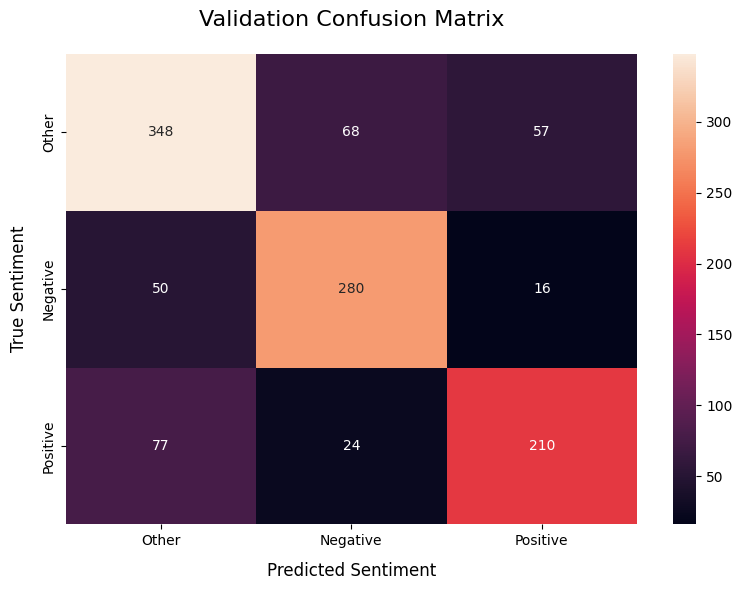

In [33]:
cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True,fmt='d',   xticklabels=class_names, yticklabels=class_names)

plt.title('Validation Confusion Matrix', fontsize=16, pad=20)
plt.xlabel('Predicted Sentiment', fontsize=12, labelpad=10)
plt.ylabel('True Sentiment', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

In [34]:
adapter_path = "/content/llama-3-sentiment-adapter"

# Save only the LoRA weights and configuration
model.save_pretrained(adapter_path)

In [ ]:
import shutil

folder_path = "/kaggle/working/llama_sentiment_model/checkpoint-2260"
zip_path = "/kaggle/working/checkpoint-2260"

shutil.make_archive(zip_path.replace('.zip', ''), 'zip', folder_path)

print("Zipped successfully!")

Zipped successfully!
